In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Create dataset
data = {
    'Name': ["A","B","C","D","E","F","G","H","I","J"],
    'Study_Hours': [2,3,4,5,6,7,8,1,9,10],
    'Attendance': [60,65,70,75,80,85,90,55,95,98],
    'Assignments': [50,55,60,65,70,75,80,45,85,90],
    'Internal_Marks': [40,45,50,55,60,65,70,35,75,80],
    'Final_Marks': [45,50,55,60,65,70,75,40,80,85]
}

df = pd.DataFrame(data)
# Add SrNo
df.insert(0, "SrNo", range(1, len(df)+1))

# Set SrNo as index
df.set_index('SrNo', inplace=True)

# Features & Target
X = df[['Study_Hours', 'Attendance', 'Assignments', 'Internal_Marks']]
y = df['Final_Marks']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Actual Marks:", list(y_test))
print("Predicted Marks:", y_pred)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Add Result column
df['Result'] = df['Final_Marks'].apply(
    lambda x: "Pass" if x >= 40 else "Fail"
)

# Reset index to show SrNo again
df = df.reset_index()

# Arrange columns properly
df = df[['SrNo','Name','Study_Hours','Attendance',
         'Assignments','Internal_Marks','Final_Marks','Result']]

# Final clean table output
print("\nFinal Data (Table Format):\n")
print(df.to_string(index=False))

Actual Marks: [80, 50]
Predicted Marks: [ 80.  50.]
Mean Squared Error: 1.26217744835e-28
R2 Score: 1.0

Final Data (Table Format):

SrNo Name  Study_Hours  Attendance  Assignments  Internal_Marks  Final_Marks Result
   1    A            2          60           50              40           45   Pass
   2    B            3          65           55              45           50   Pass
   3    C            4          70           60              50           55   Pass
   4    D            5          75           65              55           60   Pass
   5    E            6          80           70              60           65   Pass
   6    F            7          85           75              65           70   Pass
   7    G            8          90           80              70           75   Pass
   8    H            1          55           45              35           40   Pass
   9    I            9          95           85              75           80   Pass
  10    J           10     

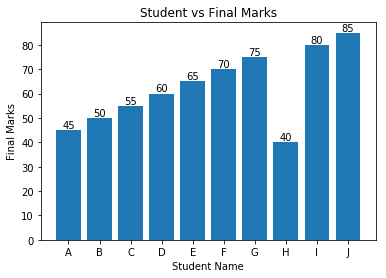

In [2]:
import matplotlib.pyplot as plt

# Bar graph: Student vs Final Marks
plt.figure()

bars = plt.bar(df['Name'], df['Final_Marks'])

# Title and labels
plt.title("Student vs Final Marks")
plt.xlabel("Student Name")
plt.ylabel("Final Marks")

# Show values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             str(yval), ha='center', va='bottom')

plt.show()